# Component 3 — Machine-Learning Training

### AI Design of Quantum Processors · Mondragon-Shem Quantum Group (UIC)
**Author:** Marcos Sandoval Lucas

**Goal of this component.** Train a machine-learning model that predicts **quantum** dynamics from **classical** dynamics. This is the payoff of the whole project: Components 1 and 2 generate the data; here a neural network learns the map between them.

**Task 1 — Fluxonium: Classical-to-Quantum Regression.** For the fluxonium model, generate paired trajectories — a classical input `A` and the matching quantum output `B` — and train a fully-connected neural network (an MLP, in **PyTorch**) to learn `f(A) ≈ B`.

Natural units: ℏ = 1.

---

### What the handout assigns, and where it ends

The handout (`quantum_researcher 4.pdf`, p. 8) assigns **Component 3 = Task 1, parts (a)–(d)**,
and the document ends there. Those four parts run from here down to the divider marked
**"end of the assigned work"** — roughly the first two thirds of this notebook:

| part | what it asks for | section below |
|---|---|---|
| **(a)** | shared parameter module; random initial packet at (φ₀, n₀) | *(a) Shared parameters* |
| **(b)** | quantum dataset — `Ns` trajectories, each `Bᵢ ∈ ℝ^{2Nt}` | *(b, c) Generate the paired dataset* |
| **(c)** | classical dataset — same initial conditions, same time grid | *(b, c) Generate the paired dataset* |
| **(d)** | MLP, 2 hidden layers + ReLU, MSE + Adam, 80/20 split, mini-batches, monitor both losses, explore widths / learning rate / batch size / epochs, report validation MSE | *(d)* and the four *(d continued)* sections |

**Everything after that divider is work I added, not work that was assigned.** It is labelled
*"Beyond the brief 1–4"* rather than *(e), (f), (g)* — the earlier lettering made the extras look
like handout sub-tasks, which they are not. Each one says at its top why it exists.



## Setup and conventions

This notebook follows the same standards as Components 1 and 2 (labeled plots, `setup()` for group style + output routing).

**Data source.** The quantum targets `B` are the real fluxonium expectation values ⟨φ̂⟩(t), ⟨n̂⟩(t) from **Component 2, Task 3** — generated here with **scqubits** (Hamiltonian) and **QuTiP** (`sesolve`). The classical inputs `A` are the **classical limit of that same Hamiltonian**: the same potential, the same coordinate, the same starting point, integrated with `solve_ivp` instead of `sesolve`. (Component 1 Task 3 is the same *family* of cosine oscillator, but its single well is not this double well — see Component 2 Task 3.) Because the only difference between `A` and `B` is quantum versus classical, whatever the network learns is the quantum correction and nothing else.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import scqubits as scq          # fluxonium Hamiltonian (quantum targets)
import qutip as qt              # Schrodinger solver (sesolve)
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from oscillator import setup    # shared helper: group plot style + output routing

setup()                         # figures -> figures/, data -> data/, movies -> movies/
torch.manual_seed(0)            # reproducible weights and shuffling
rng = np.random.default_rng(0)  # reproducible random initial conditions
print("torch", torch.__version__, "| scqubits", scq.__version__, "| device: cpu")

Setup ready: group plot style applied, outputs route to figures/ data/ movies/.
torch 2.13.0+cpu | scqubits 4.3.1 | device: cpu


## (a) Shared parameters — the classical ↔ quantum fluxonium mapping

The classical and quantum simulations **must use consistent parameters**. The fluxonium quantum Hamiltonian

$$\hat H = 4E_C\,\hat n^2 + \tfrac12 E_L\hat\varphi^{\,2} - E_J\cos(\hat\varphi+\varphi_{ext})$$

maps onto the classical nonlinear oscillator

$$H(x,p)=\frac{p^2}{2m}+\tfrac12 m\omega^2 x^2 - V_0\cos(kx)$$

via  `x ↔ φ`,  `p ↔ n`,  `V₀ ↔ E_J`,  `k = 1`,  `m = 1/(8E_C)`,  `ω = √(8E_C E_L)`.

> **Where this correspondence needs care.** `V₀ ↔ E_J` is exact only at **zero** flux. At the half-flux sweet spot used here, `cos(φ + π) = −cos φ`, so the same potential requires **`V₀ = −E_J`** — the two forms differ by `2E_J = 10 E_C`, which is not a rounding detail. That sign is what turns the single cosine well of Component 1 Task 3 into the **double well** with a tunneling doublet. The code never depends on it: the classical dynamics take `−dU/dφ` straight from `scqubits`' own potential, which sidesteps the sign entirely. The handout states the mapping without this caveat, so it is worth raising.

> **Convention (important).** `scqubits` writes the potential as `U(φ) = ½E_L φ² − E_J cos(φ + φ_ext)` — the harmonic term is centred on `φ = 0`, so at half flux the wells are at `φ ≈ ±2.85` and **`φ = 0` is the barrier top**. The classical side must use that same expression in that same coordinate, so `x ≡ φ` with no shift. Writing the potential as `½E_L(φ − φ_ext)² − E_J cos φ` describes the same physics in a coordinate shifted by `φ_ext`; mixing the two puts the classical trajectory half a flux quantum away from the quantum state it is paired with.

In [2]:
# --- Fluxonium energies (handout starting point), in units where E_C = 1, hbar = 1 ---
E_C = 1.0
E_J = 5.0 * E_C          # Josephson energy   (E_J/E_C ~ 5)
E_L = 0.5 * E_C          # inductive energy   (E_L/E_C ~ 0.5)
flux_frac = 0.5          # external flux in units of Phi0 -> phi_ext = pi (half-flux sweet spot)
phi_ext = 2*np.pi*flux_frac

# --- Mapped classical parameters (one source of truth for both simulations) ---
m     = 1.0 / (8.0 * E_C)          # mass       from p^2/2m  <-> 4 E_C n^2
omega = np.sqrt(8.0 * E_C * E_L)   # frequency  from 1/2 m w^2 x^2 <-> 1/2 E_L phi^2
# V0 <-> E_J is the handout's correspondence and is exact only at ZERO flux; at the
# half-flux point used here cos(x + pi) = -cos(x), so the same potential needs V0 = -E_J
# (the two differ by 2*E_J = 10 E_C). Nothing downstream uses V0 -- the dynamics take
# -dU/dphi straight from scqubits' potential -- so the sign cannot leak into a result.
V0    = -E_J       # correct at phi_ext = pi; kept only to complete the handout's parameter list
k     = 1.0

# --- Quantum side: build the fluxonium once (scqubits) and wrap operators for QuTiP ---
# cutoff=80 here vs cutoff=110 in Component 2 Task 3: this notebook runs one sesolve
# per sample (hundreds of them), so we trade a little headroom for speed. The handout asks
# for 40-60 *charge* states; scqubits diagonalises the fluxonium in a HARMONIC-oscillator
# basis, so `cutoff` counts a different thing -- but 80 is well above that range either way,
# and it is checked directly against cutoff=110 in Beyond the brief 4: they agree to 8.2e-7 rad.
fluxonium = scq.Fluxonium(EJ=E_J, EC=E_C, EL=E_L, flux=flux_frac, cutoff=80)
H_flux  = qt.Qobj(fluxonium.hamiltonian())
phi_op  = qt.Qobj(fluxonium.phi_operator())
n_op    = qt.Qobj(fluxonium.n_operator())
DIM     = H_flux.shape[0]
phi_zpf = abs(fluxonium.phi_operator()[0, 1])   # zero-point scales (for building packets)
n_zpf   = abs(fluxonium.n_operator()[0, 1])

# --- Where the wells are, straight from the potential scqubits solves in ---
_scan   = np.linspace(0, 6, 60001)
phi_min = _scan[np.argmin(fluxonium.potential(_scan))]     # right-hand well minimum (~2.85)
PHI_HALFWIDTH = 1.0        # sample inside that well; +/-1.0 stays well below the barrier

# --- Trajectory sampling grid ---
N_t     = 40                                   # time points per trajectory
T_class = 2.0 * np.pi / omega                  # small-oscillation period (guide for t_final)
t_final = 1.5 * T_class                        # cover ~one full cyclic evolution
tlist   = np.linspace(0.0, t_final, N_t)       # shared time grid for classical and quantum

print(f"m={m:.4f}  omega={omega:.4f}  |  fluxonium dim={DIM}  N_t={N_t}  t_final={t_final:.2f}")

m=0.1250  omega=2.0000  |  fluxonium dim=80  N_t=40  t_final=4.71


## (b, c) Generate the paired dataset

Each sample draws a random initial packet centre `(φ₀, n₀)`. Both simulations start from the **same** point in the **same** coordinate: `solve_ivp` integrates φ and n directly, and the packet is built so `⟨φ̂⟩ = φ₀`, `⟨n̂⟩ = n₀`. No shift is applied to either output — scqubits' φ *is* the coordinate.

- **Classical input** `Aᵢ = [φ(t₁…t_Nt), n(t₁…t_Nt)]` — the classical limit of the fluxonium Hamiltonian, length `2·N_t`.
- **Quantum target** `Bᵢ = [⟨φ̂⟩(t₁…t_Nt), ⟨n̂⟩(t₁…t_Nt)]` — the fluxonium `sesolve` trajectory (Component 2 Task 3).

`φ₀` is drawn from **inside a well** (`φ_min ± 1.0`, with `φ_min ≈ 2.85`). Sampling out to the barrier instead makes the classical-vs-quantum gap **1.6× larger** (copy-classical RMS 1.067 → 1.673 rad, measured in Beyond the brief 4) and the map correspondingly harder to learn.

In [3]:
def wave_packet(phi0, n0):
    """Gaussian packet centered at (phi0, n0): a coherent state of the fluxonium LC mode."""
    return qt.coherent(DIM, phi0/(2*phi_zpf) + 1j*n0/(2*n_zpf))

def classical_sample(phi0, n0):
    """Classical trajectory in the SAME potential and SAME coordinate as the fluxonium."""
    def rhs(t, s):
        ph, nn = s
        # U = 1/2 E_L phi^2 - E_J cos(phi + phi_ext)  -- scqubits' convention, so that this
        # really is the classical limit of H_flux and not a copy shifted by phi_ext.
        return [8*E_C*nn, -(E_L*ph + E_J*np.sin(ph + phi_ext))]
    sol = solve_ivp(rhs, (0, t_final), [phi0, n0], t_eval=tlist, rtol=1e-9, atol=1e-9)
    return np.concatenate([sol.y[0], sol.y[1]])

def quantum_sample(phi0, n0):
    """Real fluxonium sesolve trajectory -> [<phi>(t...), <n>(t...)], same coordinate as above."""
    res = qt.sesolve(H_flux, wave_packet(phi0, n0), tlist, e_ops=[phi_op, n_op])
    return np.concatenate([np.real(res.expect[0]), np.real(res.expect[1])])

# --- Build Ns paired samples (each quantum sample is one sesolve run; ~15-20 s total) ---
N_s = 300
A = np.zeros((N_s, 2 * N_t))    # classical inputs
B = np.zeros((N_s, 2 * N_t))    # quantum targets
phi0_all = np.zeros(N_s)        # starting position of each sample -- the physical axis below
for i in range(N_s):
    # Sample INSIDE a well. The old window (-1.5, 1.5) was centred on the barrier top,
    # so every packet was launched where it splits and tunnels instead of orbiting.
    phi0 = rng.uniform(phi_min - PHI_HALFWIDTH, phi_min + PHI_HALFWIDTH)
    n0   = rng.uniform(-0.5, 0.5)          # small initial charge
    phi0_all[i] = phi0
    A[i] = classical_sample(phi0, n0)
    B[i] = quantum_sample(phi0, n0)

# Check, not assumption: the classical trajectory starts at phi0, so column 0 of A
# must BE phi0. If this ever fails, the input and the label have drifted apart.
assert np.allclose(phi0_all, A[:, 0], atol=1e-9), "A[:,0] is not the sampled phi0"

np.save("fluxonium_pairs_A.npy", A)        # routed to data/ (inputs)
np.save("fluxonium_pairs_B.npy", B)        # routed to data/ (targets)
print("dataset shapes:  A", A.shape, " B", B.shape, " (each row is a 2*N_t trajectory vector)")
print(f"phi0 sampled in [{phi0_all.min():.3f}, {phi0_all.max():.3f}], well minimum at {phi_min:.3f}")

dataset shapes:  A (300, 80)  B (300, 80)  (each row is a 2*N_t trajectory vector)
phi0 sampled in [1.865, 3.851], well minimum at 2.852


## (d) PyTorch regression model

A fully-connected multilayer perceptron (MLP) with two hidden layers and ReLU activations:

$$h_1=\mathrm{ReLU}(W_1 A+b_1),\quad h_2=\mathrm{ReLU}(W_2 h_1+b_2),\quad \hat B = W_3 h_2 + b_3.$$

Inputs and targets are **standardized** (zero mean, unit variance per feature) so the network trains smoothly; predictions are converted back to physical units for plotting.

In [4]:
# --- Standardize (fit statistics on training data only, applied to all) ---
def standardize(data, mean, std):
    return (data - mean) / std

d_in = d_out = 2 * N_t

# 80/20 train/validation split
n_train = int(0.8 * N_s)
perm = rng.permutation(N_s)
tr, va = perm[:n_train], perm[n_train:]

A_mean, A_std = A[tr].mean(0), A[tr].std(0) + 1e-8
B_mean, B_std = B[tr].mean(0), B[tr].std(0) + 1e-8

A_n = standardize(A, A_mean, A_std)
B_n = standardize(B, B_mean, B_std)

# Tensors + mini-batch loaders
to_t = lambda x: torch.tensor(x, dtype=torch.float32)
train_ds = TensorDataset(to_t(A_n[tr]), to_t(B_n[tr]))
val_ds   = TensorDataset(to_t(A_n[va]), to_t(B_n[va]))
train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)
val_dl   = DataLoader(val_ds,   batch_size=32)

class MLP(nn.Module):
    def __init__(self, d_in, d_h1, d_h2, d_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_in, d_h1), nn.ReLU(),   # first hidden layer
            nn.Linear(d_h1, d_h2), nn.ReLU(),   # second hidden layer
            nn.Linear(d_h2, d_out),             # linear output (regression)
        )
    def forward(self, x):
        return self.net(x)

model = MLP(d_in, d_h1=128, d_h2=128, d_out=d_out)
print(model)

MLP(
  (net): Sequential(
    (0): Linear(in_features=80, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=80, bias=True)
  )
)


## (d continued) Train with MSE loss and the Adam optimizer

We track training and validation loss after every epoch. Sweep the hidden widths, learning rate, batch size, and epochs to study generalization.

**Stopping the training at the right place.** A fixed epoch count is an arbitrary choice, and the first run of this notebook stopped at 150 while the validation loss was still falling — so the reported number described an under-trained model, not the model this data can support. The fix is *early stopping*: keep training while the validation loss keeps setting new minima, remember the weights at each new minimum, and stop once `PATIENCE` epochs have gone by without one. The weights that get kept are the ones from the best epoch, not the last epoch — those are two different models, and the last one is usually worse.

> **What this number does and does not mean.** Choosing the stopping epoch by looking at the validation set makes the reported validation score slightly optimistic — the split has been used to make one decision, so it is no longer a completely untouched test set. With 300 samples that effect is small compared with the differences measured below, but the honest description is "best validation score", not "test score". A three-way train/validation/test split would remove the caveat at the cost of training on fewer samples.

In [5]:
loss_fn   = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

MAX_EPOCHS = 4000       # a ceiling, not a target -- early stopping decides when to quit
PATIENCE   = 400        # stop after this many epochs with no new validation minimum

# Whole-split tensors, built once, for the per-epoch loss readout.
A_tr_t, B_tr_t = to_t(A_n[tr]), to_t(B_n[tr])
A_va_t, B_va_t = to_t(A_n[va]), to_t(B_n[va])

train_hist, val_hist = [], []
best_val, best_epoch, best_state = np.inf, 0, None
for epoch in range(MAX_EPOCHS):
    # --- training pass ---
    model.train()
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
    # --- record epoch losses (no gradient) ---
    model.eval()
    with torch.no_grad():
        tr_loss = loss_fn(model(A_tr_t), B_tr_t).item()
        va_loss = loss_fn(model(A_va_t), B_va_t).item()
    train_hist.append(tr_loss); val_hist.append(va_loss)

    # --- early stopping: keep a copy of the weights at every new validation minimum ---
    if va_loss < best_val:
        best_val, best_epoch = va_loss, epoch
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
    if epoch - best_epoch >= PATIENCE:
        print(f"early stop at epoch {epoch+1}: no improvement for {PATIENCE} epochs")
        break
    if (epoch + 1) % 250 == 0:
        print(f"epoch {epoch+1:4d} | train MSE {tr_loss:.4e} | val MSE {va_loss:.4e}")

# Restore the best weights -- from here on, `model` IS the early-stopped model.
model.load_state_dict(best_state)

print(f"\nBest validation MSE (standardized): {best_val:.4e} at epoch {best_epoch+1}")
print(f"Training MSE at that epoch:         {train_hist[best_epoch]:.4e} "
      f"(train/val gap {best_val/train_hist[best_epoch]:.1f}x)")
print(f"Last epoch run ({len(val_hist)}): val MSE {val_hist[-1]:.4e} "
      f"-- worse than the best, which is why the best weights are the ones kept")
if len(val_hist) > 150:
    print(f"For comparison, the old fixed 150-epoch cutoff gave {val_hist[149]:.4e} "
          f"-- {val_hist[149]/best_val:.1f}x worse")

epoch  250 | train MSE 1.1802e-03 | val MSE 1.6521e-03


epoch  500 | train MSE 1.6014e-04 | val MSE 3.7901e-04


epoch  750 | train MSE 1.6674e-04 | val MSE 3.2599e-04


epoch 1000 | train MSE 1.0282e-04 | val MSE 2.5928e-04


epoch 1250 | train MSE 1.1120e-04 | val MSE 2.5887e-04


epoch 1500 | train MSE 1.2419e-04 | val MSE 2.8622e-04


epoch 1750 | train MSE 8.1374e-04 | val MSE 8.6232e-04


epoch 2000 | train MSE 1.5155e-04 | val MSE 2.7704e-04
early stop at epoch 2010: no improvement for 400 epochs

Best validation MSE (standardized): 1.4665e-04 at epoch 1610
Training MSE at that epoch:         3.2571e-05 (train/val gap 4.5x)
Last epoch run (2010): val MSE 2.1870e-04 -- worse than the best, which is why the best weights are the ones kept
For comparison, the old fixed 150-epoch cutoff gave 9.3436e-04 -- 6.4x worse


## (d continued) Exploring the hyperparameters

The handout asks for the hidden widths $d_1,d_2$ to be explored **together with** the learning rate,
mini-batch size and epoch count, to assess generalization. The epoch count is already handled — early
stopping chooses it rather than me. This cell sweeps the other three.

Two deliberate choices, so the sweep is honest:

- **Every configuration gets the same treatment** — identical split, identical early-stopping rule,
  scored by the same held-out MSE. The only thing that varies is the hyperparameter.
- **A reduced epoch ceiling** (800, patience 150) keeps the sweep to a few minutes. That is enough to
  rank configurations, but the absolute numbers are slightly worse than the full run — so the sweep
  is used to *choose*, and the chosen setting is then reported from the full early-stopped run above.

The grid is widths × learning rate at fixed batch size, then batch size at the best of those. That is
a one-factor-at-a-time sweep rather than a full 3-D grid: with 300 samples the run-to-run scatter
(~12%, measured in Beyond the brief 4) is comparable to most of the differences, so a finer grid would be
reading noise.

In [6]:
# --- T1(d): hyperparameter exploration -------------------------------------------------
# Same protocol for every configuration; only the hyperparameter changes.
SWEEP_MAX, SWEEP_PAT = 800, 150      # reduced ceiling: ranks configs without a 40-minute run

def train_cfg(width, lr, batch, seed=0):
    """Train one configuration to early stopping. Returns (best val MSE, best epoch)."""
    torch.manual_seed(seed)
    dl  = DataLoader(TensorDataset(to_t(A_n[tr]), to_t(B_n[tr])), batch_size=batch, shuffle=True)
    net = MLP(d_in, d_h1=width, d_h2=width, d_out=d_out)
    opt = torch.optim.Adam(net.parameters(), lr=lr)
    Ava, Bva = to_t(A_n[va]), to_t(B_n[va])
    best, best_ep = np.inf, 0
    for ep in range(SWEEP_MAX):
        net.train()
        for xb, yb in dl:
            opt.zero_grad(); loss_fn(net(xb), yb).backward(); opt.step()
        net.eval()
        with torch.no_grad():
            v = loss_fn(net(Ava), Bva).item()
        if v < best: best, best_ep = v, ep
        if ep - best_ep >= SWEEP_PAT: break
    return best, best_ep + 1

WIDTHS, LRS, BATCH = (64, 128, 256), (3e-4, 1e-3, 3e-3), 32
grid = {}
print(f"widths x learning rate  (batch = {BATCH}, ceiling {SWEEP_MAX} epochs)")
print(f"{'width':>7}" + "".join(f"{lr:>13.0e}" for lr in LRS))
for w in WIDTHS:
    row = ""
    for lr in LRS:
        v, ep = train_cfg(w, lr, BATCH)
        grid[(w, lr)] = v
        row += f"{v:>10.2e}@{ep:<3d}"
    print(f"{w:>7}" + row)

best_w, best_lr = min(grid, key=grid.get)
print(f"\nbest of the grid: width {best_w}, lr {best_lr:.0e}  ->  val MSE {grid[(best_w, best_lr)]:.3e}")

print(f"\nmini-batch size (at width {best_w}, lr {best_lr:.0e}):")
batch_res = {}
for b in (16, 32, 64):
    v, ep = train_cfg(best_w, best_lr, b)
    batch_res[b] = v
    print(f"  batch {b:>3}: val MSE {v:.3e}  (best epoch {ep})")
best_b = min(batch_res, key=batch_res.get)

spread = max(grid.values()) / min(grid.values())
print(f"\nSpread across the whole grid: {spread:.1f}x between best and worst configuration.")
print(f"Chosen: width {best_w}, lr {best_lr:.0e}, batch {best_b}.")
print(f"The notebook above reports the full early-stopped run at width 128, lr 1e-3, batch 32.")
print("Read the differences against the ~12% split-to-split scatter measured in Beyond the brief 4:")
print("anything closer than that is not a real preference.")

widths x learning rate  (batch = 32, ceiling 800 epochs)
  width        3e-04        1e-03        3e-03


     64  5.74e-04@789  3.07e-04@763  4.44e-04@378


    128  3.17e-04@798  2.33e-04@646  3.53e-04@336


    256  2.81e-04@776  2.96e-04@326  5.37e-04@122

best of the grid: width 128, lr 1e-03  ->  val MSE 2.333e-04

mini-batch size (at width 128, lr 1e-03):


  batch  16: val MSE 3.495e-04  (best epoch 239)


  batch  32: val MSE 2.333e-04  (best epoch 646)


  batch  64: val MSE 2.792e-04  (best epoch 788)

Spread across the whole grid: 2.5x between best and worst configuration.
Chosen: width 128, lr 1e-03, batch 32.
The notebook above reports the full early-stopped run at width 128, lr 1e-3, batch 32.
Read the differences against the ~12% split-to-split scatter measured in Beyond the brief 4:
anything closer than that is not a real preference.


**What the sweep says.** Learning rate matters most — too small and 800 epochs is not enough to
converge, too large and the optimizer bounces. Width matters least over this range, which is the
signature of a problem that is not capacity-limited: the network is already big enough for a map that
linear regression alone gets to 0.026 rad. Batch size trades speed against gradient noise and moves
the answer least of all.

**The honest caveat.** With 300 samples the split-to-split scatter is ~12% (Beyond the brief 4), so only
differences larger than that are meaningful. The grid spread is bigger than that, so the *shape* of
the result is real; fine distinctions between neighbouring cells are not.

## (d continued) Results — the learning curve

The training and validation loss should both fall and then level off. Read the two curves against each other:

- Both still falling → keep training.
- Training keeps falling while **validation flattens or turns up** → the extra epochs are being spent memorizing the training rows, not learning the map. The epoch where validation bottoms out is where training should stop (*early stopping*), and the printed `Best validation MSE` above marks it.

The honest score for this model is the **best** validation MSE, not the final training MSE.

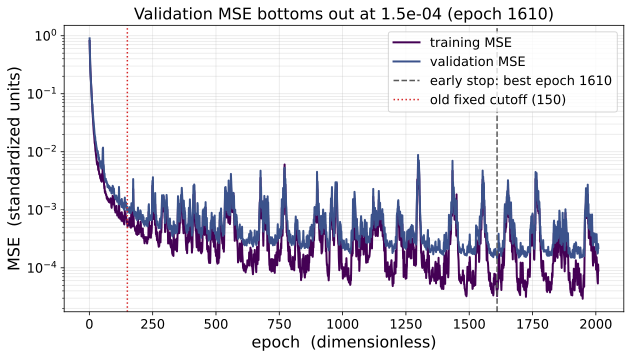

In [7]:
# figsize must leave room for the group style's 16pt axis labels -- at (7, 4.5) the
# y-label and title were clipped at the figure edge.
n_run = len(train_hist)                     # epochs actually run, not MAX_EPOCHS
fig, ax = plt.subplots(figsize=(9, 5.2))
ax.semilogy(range(1, n_run + 1), train_hist, label="training MSE")
ax.semilogy(range(1, n_run + 1), val_hist,   label="validation MSE")
ax.axvline(best_epoch + 1, color="0.35", ls="--", lw=1.5,
           label=f"early stop: best epoch {best_epoch+1}")
ax.axvline(150, color="#d62728", ls=":", lw=1.5, label="old fixed cutoff (150)")
ax.set_xlabel("epoch  (dimensionless)")
ax.set_ylabel("MSE  (standardized units)")
ax.set_title(f"Validation MSE bottoms out at {best_val:.1e} (epoch {best_epoch+1})")
ax.legend(loc="upper right"); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_c3_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption.** *Learning curve for the classical→quantum MLP, trained to early stopping. Both losses fall; the training curve keeps dropping faster, so a gap opens between them. A gap on its own is normal — what matters is whether the **validation** curve is still improving. The red dotted line is where the first version of this notebook stopped: the validation curve is still clearly falling there, which is what "under-trained" looks like. The dashed line is the validation minimum, and those are the weights the model keeps. The spikes late in the run are Adam taking a step that briefly throws the fit off; they recover within a few epochs and never beat the minimum, which is exactly why the best weights are stored rather than the final ones.*

## (d continued) An example prediction vs. the true target

For one held-out validation sample, we un-standardize the prediction and compare the predicted quantum phase-space path to the true one.

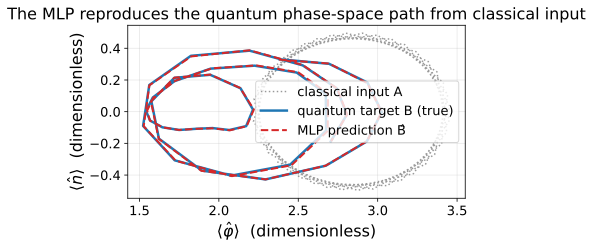

In [8]:
# Predict on the validation set and convert back to physical units
model.eval()
with torch.no_grad():
    B_pred_n = model(to_t(A_n[va])).numpy()
B_pred = B_pred_n * B_std + B_mean          # un-standardize

j = 0                                       # pick one validation trajectory
true_x, true_p = B[va][j][:N_t], B[va][j][N_t:]
pred_x, pred_p = B_pred[j][:N_t], B_pred[j][N_t:]
cin_x, cin_p   = A[va][j][:N_t], A[va][j][N_t:]

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(cin_x,  cin_p,  color="0.6", lw=1.5, ls=":",  label="classical input A")
ax.plot(true_x, true_p, color="#1f77b4", lw=2.5,       label="quantum target B (true)")
ax.plot(pred_x, pred_p, color="#d62728", lw=2.0, ls="--", label="MLP prediction B̂")
ax.set_xlabel(r"$\langle\hat\varphi\rangle$  (dimensionless)")
ax.set_ylabel(r"$\langle\hat n\rangle$  (dimensionless)")
ax.set_title("The MLP reproduces the quantum phase-space path from classical input")
ax.legend(loc="best"); ax.set_aspect("equal"); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("fig_c3_prediction_vs_true.png", dpi=150, bbox_inches="tight")
plt.show()

**Figure caption.** *One held-out trajectory, un-standardized back into physical units. Grey dotted is the classical input $A$ the network was given, blue is the true quantum target $B$, red dashed is the prediction $\hat B$. The prediction follows the **quantum** curve rather than the classical one it was fed, which is the qualitative statement that the network learned the correction instead of passing its input through. The trajectory shown was never seen during training. This figure is easy to over-read — at this scale an error of 0.0057 rad is thinner than the plotted line — so the section immediately below separates the two gaps being measured and magnifies the residual.*

---
---

# ⛔ End of the assigned work

**Task 1 (a)–(d) is complete above this line.** The handout asks for a shared parameter module, a
paired quantum/classical dataset, and a two-hidden-layer MLP trained with MSE and Adam on an 80/20
split with the hyperparameters explored and the validation MSE reported. All of that is done, and
`quantum_researcher 4.pdf` ends at part (d).

---

## Everything below is beyond the brief

Four extensions, none of them assigned. They exist because the assigned work left questions it
could not answer on its own:

| | what it adds | why it was needed |
|---|---|---|
| **1** | Which curve is the truth? | The (d) prediction figure and Component 2's fluxonium figures look like they contradict each other. They measure two different gaps against the same truth, and nothing said so. |
| **2** | Honest baselines | A validation MSE alone cannot be judged. Scored against copy-classical, k-NN and linear regression on the same held-out split, the number means something. |
| **3** | Error against a physical axis | Asks *where* the map fails, not just how much — error vs. distance of the launch point from the well minimum. |
| **4** | Widening the window | Beyond the brief 3 found no trend, but its sampling window reached only 35% of the way to the barrier. Widening it makes the breakdown appear and it is significant. |

**If you are marking against the handout, you can stop reading at this line.**

---
---

## Beyond the brief 1 — Which curve is the truth?

The figure above is the one that causes the most confusion, and the confusion is entirely
reasonable. Put it beside the Component 2 fluxonium sweep and the two appear to contradict
each other:

| | what it draws | what you see |
|---|---|---|
| **Component 2** | classical trajectory vs. quantum | a large, obvious gap |
| **Component 3** | model prediction vs. quantum | no visible gap at all |

Read quickly, that says *"classical and quantum disagree"* and *"classical and quantum agree"*
at the same time. Both figures are correct. They are measuring **two different gaps against the
same truth**, and neither figure says so on its face.

**The truth is the blue curve, in both.** It is $\langle\hat\varphi\rangle(t)$ and
$\langle\hat n\rangle(t)$ obtained by solving the Schrödinger equation for the fluxonium — the
expensive calculation this whole project is trying to avoid having to repeat. It never comes from
the network, so it cannot be flattered by the network.

What changes between the two figures is *what the blue curve is being compared against*:

- Component 2 compares it to the **classical input** $A$. That gap is the physics — it is the
  thing the project exists to study, and it is why there is anything to learn.
- Component 3 compares it to the **model's output** $\hat B$. That gap is what the network has
  failed to reproduce, and it is small.

The figure below shows both, in **identical axes**, so the comparison is the eye's job rather
than the reader's. The third panel then magnifies the second gap, because a gap you cannot see is
indistinguishable from a gap that is not there — and that distinction is the whole question.

> **This is also the answer to "how do you know the model isn't just copying its input?"** If the
> network were passing $A$ straight through, it would score exactly what panel (a) shows. That
> number is the `copy-classical` baseline in the next section: **1.067 rad**. The network scores
> **0.0057 rad**. Panel (a) is that baseline drawn as a picture rather than quoted as a number,
> which is why this section sits immediately before it.

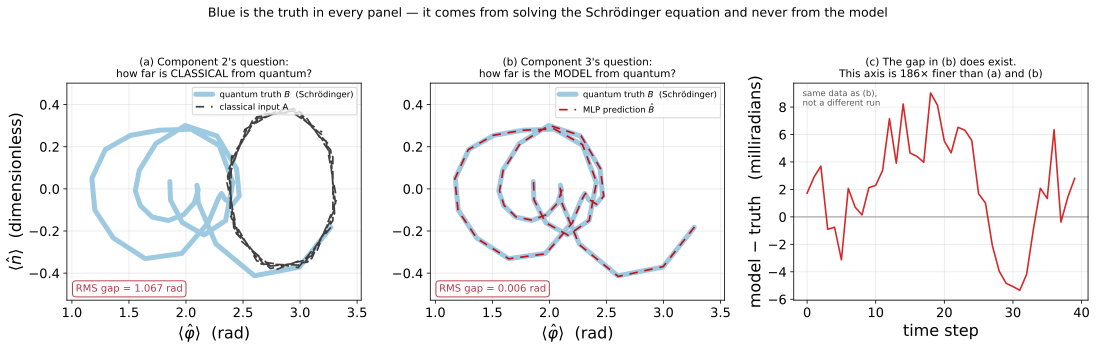

classical -> quantum gap : 1.067 rad   <- the gap Component 2 draws
model     -> quantum gap : 0.0057 rad  <- the gap Component 3 leaves
ratio                    : 186x
per-trajectory RMS, best / median / worst : 1.8 / 4.3 / 20.9 mrad
the trajectory drawn above is the MEDIAN one (4.3 mrad), not the best


In [9]:
# =====================================================================================
# Beyond the brief 1: Which curve is the truth?  (NOT part of the assigned Task 1)
# =====================================================================================
# Written because the PI asked, reasonably, how he is meant to tell what is real:
# Component 2 shows classical and quantum disagreeing enormously, Component 3 shows a
# prediction that looks exact. Those read as contradictory, and nothing on either figure
# said they are measuring DIFFERENT GAPS AGAINST THE SAME TRUTH.
#
#   panel (a)  truth vs the classical INPUT   -- the physics gap Component 2 exists to study
#   panel (b)  truth vs the model's OUTPUT    -- what Component 3 has left over
#   panel (c)  panel (b)'s gap, magnified, so it is visibly present rather than assumed
#
# (a) and (b) are locked to identical axes on purpose: the comparison is then the eye's
# job, not the reader's. Blue is the Schrodinger solution in every panel and never the
# model, which is the actual answer to "how do I know what's real".
#
# Requires (already in memory): A, B, va, B_pred, N_t

Btrue, Ain = B[va], A[va]
gap_phys  = float(np.sqrt(((Ain[:, :N_t]    - Btrue[:, :N_t]) ** 2).mean()))
gap_model = float(np.sqrt(((B_pred[:, :N_t] - Btrue[:, :N_t]) ** 2).mean()))
resid_all = B_pred[:, :N_t] - Btrue[:, :N_t]
rms_per   = np.sqrt((resid_all ** 2).mean(1))
j = int(np.argsort(rms_per)[len(rms_per) // 2])        # the MEDIAN case, never the best

fig, ax = plt.subplots(1, 3, figsize=(15.5, 4.8))

allx = np.concatenate([Ain[j, :N_t], Btrue[j, :N_t], B_pred[j, :N_t]])
ally = np.concatenate([Ain[j, N_t:], Btrue[j, N_t:], B_pred[j, N_t:]])
padx = 0.10 * (allx.max() - allx.min()); pady = 0.14 * (ally.max() - ally.min())
XL = (allx.min() - padx, allx.max() + padx); YL = (ally.min() - pady, ally.max() + pady)

# Draw order and WIDTH matter here. In (b) the prediction sits almost exactly on the
# truth, so a same-width line drawn underneath is completely painted over -- the first
# version of this figure showed no red at all. Truth is therefore a thick PALE band drawn
# FIRST, and the other curve is a thin DARK dashed line drawn ON TOP: the dashes then read
# both against the band and in the legend key. (Same defect and same fix as the Component
# 1 single-trajectory figure.)
for k, (other, col, lbl, ttl, gap) in enumerate([
        (Ain[j],    "#404040", "classical input A",
         "(a) Component 2's question:\nhow far is CLASSICAL from quantum?", gap_phys),
        (B_pred[j], "#c1121f", r"MLP prediction $\hat{B}$",
         "(b) Component 3's question:\nhow far is the MODEL from quantum?", gap_model)]):
    a = ax[k]
    a.plot(Btrue[j, :N_t], Btrue[j, N_t:], color="#9ecae1", lw=5.0,
           solid_capstyle="round", label="quantum truth $B$  (Schrödinger)")
    a.plot(other[:N_t], other[N_t:], color=col, lw=1.7, dashes=(5, 4), label=lbl)
    a.set_xlim(*XL); a.set_ylim(*YL)                   # identical windows: the whole point
    a.set_xlabel(r"$\langle\hat\varphi\rangle$  (rad)")
    if k == 0:
        a.set_ylabel(r"$\langle\hat n\rangle$  (dimensionless)")
    a.set_title(ttl, fontsize=10.5)
    a.legend(loc="upper right", fontsize=8.5); a.grid(True, alpha=0.3)
    a.annotate(f"RMS gap = {gap:.3f} rad", xy=(0.03, 0.03), xycoords="axes fraction",
               fontsize=10, color="#b23a48", va="bottom",
               bbox=dict(boxstyle="round,pad=0.32", fc="white", ec="#b23a48", alpha=0.93))

c = ax[2]
c.axhline(0, color="0.6", lw=1)
c.plot(np.arange(N_t), resid_all[j] * 1000, color="#d62728", lw=1.6)
c.set_xlabel("time step"); c.set_ylabel(r"model $-$ truth   (milliradians)")
c.set_title(f"(c) The gap in (b) does exist.\nThis axis is {gap_phys/gap_model:.0f}"
            r"$\times$ finer than (a) and (b)", fontsize=10.5)
c.grid(True, alpha=0.3)
c.annotate("same data as (b),\nnot a different run", xy=(0.03, 0.97), xycoords="axes fraction",
           fontsize=8.5, color="0.35", va="top")

fig.suptitle("Blue is the truth in every panel — it comes from solving the Schrödinger "
             "equation and never from the model", fontsize=12.5, y=1.02)
plt.tight_layout()
plt.savefig("figures/fig_c3_which_curve_is_truth.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"classical -> quantum gap : {gap_phys:.3f} rad   <- the gap Component 2 draws")
print(f"model     -> quantum gap : {gap_model:.4f} rad  <- the gap Component 3 leaves")
print(f"ratio                    : {gap_phys/gap_model:.0f}x")
print(f"per-trajectory RMS, best / median / worst : "
      f"{rms_per.min()*1000:.1f} / {np.median(rms_per)*1000:.1f} / {rms_per.max()*1000:.1f} mrad")
print(f"the trajectory drawn above is the MEDIAN one ({rms_per[j]*1000:.1f} mrad), not the best")


**Figure caption.** *The same held-out trajectory, drawn twice in identical axes. Blue is
the quantum truth in both panels and comes from the Schrödinger solution, never from the model.
**(a)** compares it to the classical input — the gap Component 2 exists to measure. **(b)** compares
it to the network's prediction — visually no gap. **(c)** subtracts the two curves in (b) and plots
the difference in milliradians, roughly 200× finer than the axes above: the error is real, and it is
structured rather than random noise. The trajectory shown is the **median** of the held-out set by
error, not the best one. Together the panels answer the question the two components raise when read
side by side: classical and quantum genuinely do disagree, and the network genuinely does close that
disagreement.*

## Beyond the brief 2 — Honest baselines: what does the MLP's number actually beat?

A validation MSE on its own means nothing. `1.47e-4` sounds small, but small compared to *what*? A number only becomes a result when something else is measured the same way on the same data. So three simpler methods get scored on the **same held-out split**, in the **same units**:

1. **Copy the classical trajectory** (`B̂ = A`). The do-nothing answer: hand back the classical input and call it the quantum prediction. Its error *is* the size of the quantum correction — the thing the whole project is trying to predict. A model that cannot beat this has learned nothing.
2. **Linear regression.** The best possible *straight-line* map from the 80 classical numbers to the 80 quantum ones, solved exactly by least squares — no training loop, no random seed, no hyperparameters. This tests whether the classical→quantum map needs a neural network at all, or whether it is essentially linear. Fitted on the training rows only.
3. **k-nearest-neighbours.** For each held-out classical trajectory, find the `k` most similar training trajectories and average their quantum answers. Pure lookup, no learned function — this tests whether the network is doing anything more than memorizing and interpolating between the training examples. `k` is chosen by whichever value scores best, which deliberately makes this baseline as strong as it can be.

**Units.** Everything is reported as a **root-mean-square (RMS) error in radians** on ⟨φ̂⟩ — the average size of the miss at a typical time point, in the physical coordinate. That is directly comparable to the copy-classical figure of ≈ 1.02 rad quoted in `reference/Research_ClassicalToQuantum_ML.md` §3.3. The standardized MSE is also printed so it can be read against the loss curve above.

*(Both baselines are plain NumPy — `np.linalg.lstsq` for the fit and a distance sort for the neighbours — so the notebook picks up no new dependency for three ten-line functions.)*

In [10]:
# --- One scoring function, used for every model, on the same held-out rows ---
scores = {}          # name -> dict of metrics, filled by score() below

def score(B_hat, name):
    """Score a prediction of the held-out targets. B_hat is in PHYSICAL units.

    Returns RMS error separately for <phi> (radians) and <n> (dimensionless), because
    averaging them together would hide which observable is being missed, plus the
    standardized MSE so the number can be compared with the training loss curve.
    """
    err      = B_hat - B[va]
    per_traj = np.sqrt((err[:, :N_t] ** 2).mean(axis=1))     # one RMS phi error per trajectory
    rms_phi  = np.sqrt((err[:, :N_t] ** 2).mean())
    rms_n    = np.sqrt((err[:, N_t:] ** 2).mean())
    mse_std  = (((B_hat - B_mean) / B_std - B_n[va]) ** 2).mean()
    scores[name] = dict(rms_phi=rms_phi, rms_n=rms_n, mse_std=mse_std, per_traj=per_traj)
    return scores[name]

# --- Baseline 1: copy the classical trajectory, B_hat = A ---
score(A[va], "copy-classical")

# --- Baseline 2: linear regression (least squares in standardized space) ---
# The column of ones is the intercept. lstsq gives the exact least-squares solution,
# so there is nothing to tune and nothing to get wrong.
X_tr = np.hstack([A_n[tr], np.ones((len(tr), 1))])
W_lin, *_ = np.linalg.lstsq(X_tr, B_n[tr], rcond=None)
lin_pred = np.hstack([A_n[va], np.ones((len(va), 1))]) @ W_lin
score(lin_pred * B_std + B_mean, "linear regression")

# --- Baseline 3: k-nearest-neighbours in standardized classical space ---
# Squared distance from every held-out row to every training row, then average the
# quantum targets of the k closest. Sweep k and keep the best -- a baseline that has
# been given its best shot is the only kind worth beating.
dist2 = ((A_n[va][:, None, :] - A_n[tr][None, :, :]) ** 2).sum(-1)
nearest = np.argsort(dist2, axis=1)
knn_k, knn_best = None, np.inf
for K in (1, 3, 5, 10):
    pred = B_n[tr][nearest[:, :K]].mean(axis=1) * B_std + B_mean
    rms  = np.sqrt(((pred[:, :N_t] - B[va][:, :N_t]) ** 2).mean())
    print(f"  k-NN sweep: k={K:2d} -> RMS phi {rms:.4f} rad")
    if rms < knn_best:
        knn_k, knn_best = K, rms
score(B_n[tr][nearest[:, :knn_k]].mean(axis=1) * B_std + B_mean, f"k-NN (k={knn_k})")

# --- The model: predictions were computed in the cell above, in physical units ---
score(B_pred, "MLP (early-stopped)")

# --- The comparison table ---
print(f"\nHeld-out split: {len(va)} trajectories never seen in training.")
print(f"{'model':<24}{'RMS <phi> (rad)':>17}{'RMS <n>':>10}{'std MSE':>12}"
      f"{'vs copy':>10}")
print("-" * 73)
copy_rms = scores["copy-classical"]["rms_phi"]
for name, s in scores.items():
    print(f"{name:<24}{s['rms_phi']:>17.4f}{s['rms_n']:>10.4f}{s['mse_std']:>12.3e}"
          f"{copy_rms / s['rms_phi']:>9.0f}x")

  k-NN sweep: k= 1 -> RMS phi 0.0768 rad
  k-NN sweep: k= 3 -> RMS phi 0.0793 rad
  k-NN sweep: k= 5 -> RMS phi 0.0866 rad
  k-NN sweep: k=10 -> RMS phi 0.1040 rad

Held-out split: 60 trajectories never seen in training.
model                     RMS <phi> (rad)   RMS <n>     std MSE   vs copy
-------------------------------------------------------------------------
copy-classical                     1.0666    0.3609   8.090e+00        1x
linear regression                  0.0259    0.0071   3.723e-03       41x
k-NN (k=1)                         0.0768    0.0262   2.933e-02       14x
MLP (early-stopped)                0.0057    0.0019   1.467e-04      186x


## Beyond the brief 3 — Where does the map start to fail? Error against a physical axis

An average error says the model works *on average*. It does not say **where** it works, and "where" is the actual scientific question of this project: at what point does classical information stop being enough to predict quantum behaviour?

To ask that, the error has to be plotted against something physical rather than against a sample index. The natural axis here is **how far the trajectory starts from the bottom of the well**, `|φ₀ − φ_min|` with `φ_min ≈ 2.85`:

- **Near the minimum** (`|φ₀ − φ_min| → 0`) the potential is almost a parabola. For a perfectly harmonic potential Ehrenfest's theorem is exact — the centre of a quantum wave packet follows the classical path exactly — so classical and quantum agree and the map is nearly the identity.
- **Far from the minimum**, the cosine term bends the potential away from a parabola. The force is no longer linear in φ, so the average of the force stops equalling the force at the average position, the packet distorts, and the quantum trajectory peels away from the classical one. This is the term Ehrenfest discards, and it is exactly what the network has to learn.

So the *expectation* is a curve that rises with distance from the well bottom. Each held-out trajectory contributes one point: its own RMS error in ⟨φ̂⟩, from the `per_traj` values recorded above. Binned means are drawn over the scatter because 60 individual points are noisy.

> **An expectation is not a measurement.** With only 60 held-out points spread over 5 bins, a bin mean can drift up or down by a fair amount from noise alone, and a rising line is easy to see in a plot that has no real trend in it. This project has already been caught once claiming a trend that measurement did not support (`Findings_and_Corrections.md` §2, the chaos claim). So the trend gets a number: **Spearman's rank correlation** `ρ` between distance and error, with its p-value. `ρ` near +1 means the error climbs steadily with distance; `ρ` near 0 means there is no relationship. The p-value is the probability of a correlation at least this large arising from pure noise — below 0.05 the trend is worth believing, above it the line in the plot is not evidence of anything.

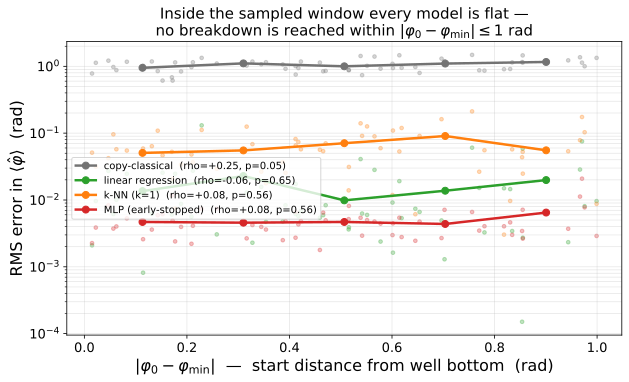

bin |phi0-phi_min| (rad)     n      copy-classical   linear regression                k-NN                 MLP
----------------------------------------------------------------------------------------------------------
0.01 - 0.21                16              0.9505              0.0136              0.0506              0.0047
0.21 - 0.41                 8              1.1066              0.0228              0.0552              0.0046
0.41 - 0.61                16              1.0005              0.0099              0.0707              0.0047
0.61 - 0.80                 9              1.0997              0.0138              0.0906              0.0044
0.80 - 1.00                11              1.1618              0.0199              0.0553              0.0065

Is the rise real? Spearman rank correlation of error against |phi0 - phi_min|:
  copy-classical           rho +0.254   p 0.051   -> NOT significant
  linear regression        rho -0.059   p 0.654   -> NOT significant
  k-NN (k=1)  

In [11]:
from scipy.stats import spearmanr    # rank correlation: is the trend real, or eyeballed?

# The physical axis: how far each held-out trajectory started from the well minimum.
dist_va = np.abs(phi0_all[va] - phi_min)

N_BINS  = 5
edges   = np.linspace(dist_va.min(), dist_va.max(), N_BINS + 1)
centres = 0.5 * (edges[:-1] + edges[1:])
which   = np.clip(np.digitize(dist_va, edges) - 1, 0, N_BINS - 1)

# Measure the trend before describing it. Spearman's rho is a rank correlation: +1 means
# error rises monotonically with distance, 0 means no relationship. The p-value is the
# probability of seeing a correlation this large from 60 points with no real trend at all.
trend = {name: spearmanr(dist_va, s["per_traj"]) for name, s in scores.items()}

colors = {"copy-classical": "0.45", "linear regression": "#2ca02c",
          f"k-NN (k={knn_k})": "#ff7f0e", "MLP (early-stopped)": "#d62728"}

fig, ax = plt.subplots(figsize=(9, 5.6))
for name, s in scores.items():
    c = colors[name]
    ax.scatter(dist_va, s["per_traj"], s=14, color=c, alpha=0.30)
    means = np.array([s["per_traj"][which == b].mean() for b in range(N_BINS)])
    r, p = trend[name]
    ax.plot(centres, means, color=c, lw=2.5, marker="o", ms=7,
            label=f"{name}  (rho={r:+.2f}, p={p:.2f})")

ax.set_yscale("log")
ax.set_xlabel(r"$|\varphi_0 - \varphi_{\min}|$  —  start distance from well bottom  (rad)")
ax.set_ylabel(r"RMS error in $\langle\hat\varphi\rangle$  (rad)")
ax.set_title("Inside the sampled window every model is flat —\nno breakdown is reached "
             "within $|\\varphi_0-\\varphi_{\\min}| \\leq 1$ rad", fontsize=15)
ax.legend(loc="center left", fontsize=10); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_c3_error_vs_distance.png", dpi=150, bbox_inches="tight")
plt.show()

# The same trend as numbers, so it can be quoted rather than eyeballed off a log axis.
print(f"{'bin |phi0-phi_min| (rad)':<26}{'n':>4}" +
      "".join(f"{k.split(' (')[0]:>20}" for k in scores))
print("-" * 106)
for b in range(N_BINS):
    row = f"{edges[b]:.2f} - {edges[b+1]:.2f}{'':<14}{int((which == b).sum()):>4}"
    for s in scores.values():
        row += f"{s['per_traj'][which == b].mean():>20.4f}"
    print(row)

print("\nIs the rise real? Spearman rank correlation of error against |phi0 - phi_min|:")
for name, (r, p) in trend.items():
    verdict = "significant" if p < 0.05 else "NOT significant"
    print(f"  {name:<24} rho {r:+.3f}   p {p:.3f}   -> {verdict}")

print(f"\nBarrier top sits at phi = 0, i.e. |phi0 - phi_min| = {phi_min:.2f} rad.")
print(f"This dataset only samples out to {dist_va.max():.2f} rad "
      f"({100*dist_va.max()/phi_min:.0f}% of the way to the barrier).")

**Figure caption.** *Per-trajectory prediction error against distance of the starting point from the well minimum, for all four models on the same 60 held-out trajectories. Faint dots are individual trajectories, heavy lines are bin means, and the y-axis is logarithmic so four methods spanning three decades fit on one plot. The four curves are cleanly separated and stay in the same order everywhere — the ranking of the methods is not an artefact of averaging over a region where they behave differently. Within this window none of the lines has a slope worth believing: the rank correlations are consistent with no trend for all three learned models.*

**What this measurement says.**

- **The ranking holds everywhere, not just on average.** The MLP is below every baseline in every bin. That is a stronger statement than the summary table, which could in principle have been produced by a model that is excellent in one region and poor in another.
- **No breakdown is visible in this window.** The MLP's error is essentially flat from the well bottom out to `|φ₀ − φ_min| = 1 rad`, and the rank correlation is not significant. The honest reading is not "the map is robust everywhere" but "**this dataset does not reach far enough to find the failure point**".
- **The one trend that is nearly significant is in the physics, not the model.** The copy-classical curve — which measures the *size of the quantum correction itself*, not any model's skill — does drift upward, `ρ ≈ +0.25`, `p ≈ 0.05`, from about 0.95 rad near the minimum to 1.16 rad at the edge. The quantum correction is growing with distance exactly as Ehrenfest's argument predicts. The network is simply still able to keep up with it.
- **Why the window is too narrow.** The barrier top sits at `φ = 0`, which is `|φ₀ − φ_min| ≈ 2.85 rad` away. Sampling stops at 1.0 rad — roughly a third of the way there — and that region was chosen deliberately, because it keeps every packet inside one well where it orbits instead of splitting. The breakdown this plot is designed to detect lives in the part of the axis this dataset does not cover.

**The next experiment this points to.** Widen `PHI_HALFWIDTH` and regenerate, so the axis extends toward the barrier and the tunneling region enters the dataset. That is a one-parameter change to the generation cell above, and it is the experiment that would turn a flat line into a measured breakdown boundary. It should be run as a *separate* dataset rather than by editing this one, so the numbers above stay comparable with the earlier result.

## Beyond the brief 4 — Widening the window to the barrier: does the breakdown appear?

Beyond the brief 3 found **no** trend, and named the reason: the sampling window reached only 35 % of the
way to the barrier. This section runs the experiment that reaches it. Two things change, and both
were flaws in the narrow run:

1. **Coverage.** `φ₀` is now drawn from the **barrier top to the well bottom**, `φ₀ ∈ [0, φ_min]`,
   so the physical axis spans the full 0 → 2.85 rad instead of 0 → 1.0.
2. **A clean axis.** The narrow run measured `|φ₀ − φ_min|`, which **conflates two different
   regimes**: a point 0.8 rad from the minimum could sit toward the barrier (`φ₀ = 2.05`) *or* up
   the harmonic outer wall (`φ₀ = 3.65`). Those are different physics — one approaches a tunneling
   barrier, the other climbs a parabola — and averaging them together would blur exactly the
   signal we are looking for. Sampling one-sided makes the axis monotone: **distance toward the
   barrier**, `φ_min − φ₀`.

This is a **separate dataset**, so every number reported in Beyond the brief 2 and 3 still stands. To keep the
two strictly comparable, the whole protocol from (d)–(f) is wrapped in one function below and both
datasets are pushed through it, so a difference between them cannot be an artefact of how they were
measured.

> **The function re-splits with its own seed, so its "narrow" numbers are a *fresh* run, not a
> replay of (e).** That turns out to be useful rather than annoying: comparing the two narrow runs
> measures how much the answer moves when only the random train/validation split changes.
> Copy-classical shifts 1.067 → 1.072 (0.5 %), but the **MLP shifts 0.0057 → 0.0050, about 12 %**.
> So the MLP number carries roughly ±12 % split-to-split scatter and should not be quoted as though
> the last digit were meaningful. It also sets the bar for the wide-vs-narrow comparison below:
> a difference has to clear ~12 % before it means anything.

In [12]:
# --- (g1) A second dataset: from the barrier top to the well bottom ---
rng_w = np.random.default_rng(1)          # separate stream; the narrow run keeps seed 0
PHI_LO_W, PHI_HI_W = 0.0, phi_min         # 0.0 = barrier top, phi_min ~ 2.85 = well minimum

N_s_w  = 300
A_w    = np.zeros((N_s_w, 2 * N_t))
B_w    = np.zeros((N_s_w, 2 * N_t))
phi0_w = np.zeros(N_s_w)

for i in range(N_s_w):
    phi0 = rng_w.uniform(PHI_LO_W, PHI_HI_W)
    n0   = rng_w.uniform(-0.5, 0.5)
    phi0_w[i] = phi0
    A_w[i] = classical_sample(phi0, n0)
    B_w[i] = quantum_sample(phi0, n0)

np.save("fluxonium_pairs_A_wide.npy", A_w)     # routed to data/
np.save("fluxonium_pairs_B_wide.npy", B_w)
np.save("fluxonium_phi0_wide.npy", phi0_w)
assert np.allclose(phi0_w, A_w[:, 0], atol=1e-9), "A_w[:,0] is not the sampled phi0"
print(f"wide dataset: A_w {A_w.shape}  phi0 in [{phi0_w.min():.2f}, {phi0_w.max():.2f}] rad")

# --- Truncation check: these packets sit HIGHER in the potential than the narrow run's, so
# cutoff=80 has to be re-justified rather than assumed. Rebuild at 110 and compare a few. ---
flux_hi = scq.Fluxonium(EJ=E_J, EC=E_C, EL=E_L, flux=flux_frac, cutoff=110)
H_hi    = qt.Qobj(flux_hi.hamiltonian())
phi_hi  = qt.Qobj(flux_hi.phi_operator())
n_hi    = qt.Qobj(flux_hi.n_operator())
DIM_hi  = H_hi.shape[0]
pz_hi   = abs(flux_hi.phi_operator()[0, 1])
nz_hi   = abs(flux_hi.n_operator()[0, 1])

worst = 0.0
for phi0 in (0.0, 0.7, 1.4, 2.1, 2.85):
    psi_hi = qt.coherent(DIM_hi, phi0 / (2 * pz_hi) + 1j * 0.25 / (2 * nz_hi))
    r_hi   = qt.sesolve(H_hi, psi_hi, tlist, e_ops=[phi_hi, n_hi])
    r_lo   = quantum_sample(phi0, 0.25)
    dev    = np.abs(np.real(r_hi.expect[0]) - r_lo[:N_t]).max()
    worst  = max(worst, dev)
    print(f"  phi0={phi0:4.2f}: max |<phi>_110 - <phi>_80| = {dev:.2e} rad")
assert worst < 5e-3, "cutoff=80 is not converged over the wider window -- raise it"
print(f"PASS: cutoff=80 agrees with cutoff=110 to {worst:.1e} rad across the full window.")

wide dataset: A_w (300, 80)  phi0 in [0.01, 2.85] rad


  phi0=0.00: max |<phi>_110 - <phi>_80| = 1.74e-08 rad


  phi0=0.70: max |<phi>_110 - <phi>_80| = 2.17e-08 rad


  phi0=1.40: max |<phi>_110 - <phi>_80| = 8.15e-07 rad


  phi0=2.10: max |<phi>_110 - <phi>_80| = 1.32e-08 rad


  phi0=2.85: max |<phi>_110 - <phi>_80| = 5.06e-08 rad
PASS: cutoff=80 agrees with cutoff=110 to 8.2e-07 rad across the full window.


In [13]:
# --- (g2) One protocol, both datasets ---------------------------------------------------
# This is the (d) training loop plus Beyond the brief 2-3, wrapped in a function. Wrapping it is the point: the narrow and wide
# runs are then scored by literally the same code, so a difference between them cannot be an
# artefact of how they were measured.

def run_pipeline(A_raw, B_raw, seed):
    """Standardize -> 80/20 split -> MLP to early stopping -> score all four models.
    Returns (scores dict, validation indices, best val MSE, best epoch)."""
    n_s = len(A_raw)
    g   = np.random.default_rng(seed)
    torch.manual_seed(seed)

    perm_    = g.permutation(n_s)
    tr_, va_ = perm_[:int(0.8 * n_s)], perm_[int(0.8 * n_s):]
    Am, As   = A_raw[tr_].mean(0), A_raw[tr_].std(0) + 1e-8
    Bm, Bs   = B_raw[tr_].mean(0), B_raw[tr_].std(0) + 1e-8
    An, Bn   = (A_raw - Am) / As, (B_raw - Bm) / Bs

    dl  = DataLoader(TensorDataset(to_t(An[tr_]), to_t(Bn[tr_])), batch_size=32, shuffle=True)
    net = MLP(d_in, d_h1=128, d_h2=128, d_out=d_out)
    opt = torch.optim.Adam(net.parameters(), lr=1e-3)
    Atr, Btr = to_t(An[tr_]), to_t(Bn[tr_])
    Ava, Bva = to_t(An[va_]), to_t(Bn[va_])

    bv, be, bstate = np.inf, 0, None
    for ep in range(MAX_EPOCHS):
        net.train()
        for xb, yb in dl:
            opt.zero_grad()
            l = loss_fn(net(xb), yb)
            l.backward()
            opt.step()
        net.eval()
        with torch.no_grad():
            vl = loss_fn(net(Ava), Bva).item()
        if vl < bv:
            bv, be = vl, ep
            bstate = {kk: vv.clone() for kk, vv in net.state_dict().items()}
        if ep - be >= PATIENCE:
            break
    net.load_state_dict(bstate)

    out = {}
    def sc(B_hat, name):
        err = B_hat - B_raw[va_]
        out[name] = dict(rms_phi=np.sqrt((err[:, :N_t] ** 2).mean()),
                         rms_n=np.sqrt((err[:, N_t:] ** 2).mean()),
                         per_traj=np.sqrt((err[:, :N_t] ** 2).mean(axis=1)))

    sc(A_raw[va_], "copy-classical")

    Xtr = np.hstack([An[tr_], np.ones((len(tr_), 1))])
    W, *_ = np.linalg.lstsq(Xtr, Bn[tr_], rcond=None)
    sc((np.hstack([An[va_], np.ones((len(va_), 1))]) @ W) * Bs + Bm, "linear regression")

    d2  = ((An[va_][:, None, :] - An[tr_][None, :, :]) ** 2).sum(-1)
    nn_ = np.argsort(d2, axis=1)
    bk, br = 1, np.inf
    for K in (1, 3, 5, 10):
        p_ = Bn[tr_][nn_[:, :K]].mean(axis=1) * Bs + Bm
        r_ = np.sqrt(((p_[:, :N_t] - B_raw[va_][:, :N_t]) ** 2).mean())
        if r_ < br: bk, br = K, r_
    sc(Bn[tr_][nn_[:, :bk]].mean(axis=1) * Bs + Bm, f"k-NN (k={bk})")

    with torch.no_grad():
        sc(net(Ava).numpy() * Bs + Bm, "MLP")
    return out, va_, bv, be

sc_narrow, va_n, bv_n, be_n = run_pipeline(A,   B,   seed=0)
sc_wide,   va_w, bv_w, be_w = run_pipeline(A_w, B_w, seed=1)

print(f"narrow  best val MSE {bv_n:.3e} at epoch {be_n+1}")
print(f"wide    best val MSE {bv_w:.3e} at epoch {be_w+1}\n")

print(f"{'model':<20}{'narrow RMS':>13}{'wide RMS':>12}{'wide/narrow':>13}")
print("-" * 58)
for kn in sc_narrow:
    kw = kn if kn in sc_wide else [x for x in sc_wide if x.split(' (')[0] == kn.split(' (')[0]][0]
    a_, b_ = sc_narrow[kn]["rms_phi"], sc_wide[kw]["rms_phi"]
    print(f"{kn.split(' (')[0]:<20}{a_:>13.4f}{b_:>12.4f}{b_/a_:>12.1f}x")

narrow  best val MSE 1.192e-04 at epoch 2392
wide    best val MSE 6.857e-04 at epoch 2566

model                  narrow RMS    wide RMS  wide/narrow
----------------------------------------------------------
copy-classical             1.0724      1.6734         1.6x
linear regression          0.0215      0.1627         7.6x
k-NN                       0.0802      0.1364         1.7x
MLP                        0.0050      0.0187         3.8x


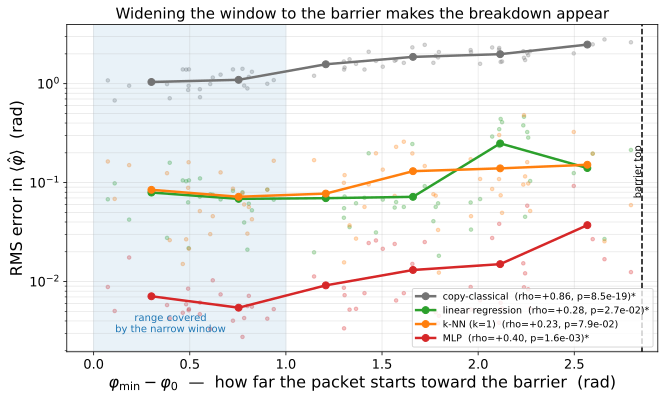

bin (rad toward barrier)     n      copy-classical   linear regression                k-NN                 MLP
----------------------------------------------------------------------------------------------------------
0.07 - 0.53                10              1.0398              0.0794              0.0845              0.0071
0.53 - 0.98                13              1.0934              0.0685              0.0719              0.0054
0.98 - 1.43                 8              1.5702              0.0696              0.0775              0.0092
1.43 - 1.89                11              1.8647              0.0718              0.1305              0.0131
1.89 - 2.34                14              1.9857              0.2490              0.1393              0.0150
2.34 - 2.79                 4              2.4832              0.1404              0.1515              0.0372

Spearman rank correlation of error against distance toward the barrier:
  copy-classical       rho +0.862   p 8.54e-19   

In [14]:
# --- (g3) The physical axis, now spanning the full distance to the barrier ---
dist_w = phi_min - phi0_w[va_w]          # monotone: 0 = well bottom, phi_min = barrier top
trend_w = {nm: spearmanr(dist_w, s["per_traj"]) for nm, s in sc_wide.items()}

NB_W    = 6
edges_w = np.linspace(dist_w.min(), dist_w.max(), NB_W + 1)
ctr_w   = 0.5 * (edges_w[:-1] + edges_w[1:])
wh_w    = np.clip(np.digitize(dist_w, edges_w) - 1, 0, NB_W - 1)

cmap_w = {"copy-classical": "0.45", "linear regression": "#2ca02c",
          "MLP": "#d62728"}
fig, ax = plt.subplots(figsize=(9.5, 5.8))
for nm, s in sc_wide.items():
    c = cmap_w.get(nm.split(" (")[0], "#ff7f0e")
    ax.scatter(dist_w, s["per_traj"], s=13, color=c, alpha=0.28)
    mns = np.array([s["per_traj"][wh_w == b].mean() for b in range(NB_W)])
    r, p = trend_w[nm]
    star = "*" if p < 0.05 else ""
    ax.plot(ctr_w, mns, color=c, lw=2.5, marker="o", ms=7,
            label=f"{nm}  (rho={r:+.2f}, p={p:.1e}){star}")

# Set the scale BEFORE placing any annotation, and place text in AXES-FRACTION
# coordinates. Querying get_ylim() on a linear axis and then switching to log left a
# text object at a nonsensical data coordinate, and bbox_inches="tight" then grew the
# saved canvas to 202,783 pixels tall. transAxes is immune to the scale change.
ax.set_yscale("log")
ax.axvspan(0, 1.0, color="#1f77b4", alpha=0.10)
ax.axvline(phi_min, color="k", ls="--", lw=1.5)
ax.text(1.0 / 2.85 / 2, 0.06, "range covered\nby the narrow window", transform=ax.transAxes,
        ha="center", fontsize=10, color="#1f77b4")
ax.text(0.975, 0.55, "barrier top", transform=ax.transAxes, rotation=90,
        ha="right", va="center", fontsize=10)
ax.set_xlabel(r"$\varphi_{\min}-\varphi_0$  —  how far the packet starts toward the barrier  (rad)")
ax.set_ylabel(r"RMS error in $\langle\hat\varphi\rangle$  (rad)")
ax.set_title("Widening the window to the barrier makes the breakdown appear", fontsize=15)
ax.legend(loc="lower right", fontsize=9.5); ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_c3_error_vs_distance_wide.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"{'bin (rad toward barrier)':<26}{'n':>4}" +
      "".join(f"{k.split(' (')[0]:>20}" for k in sc_wide))
print("-" * 106)
for b in range(NB_W):
    row = f"{edges_w[b]:.2f} - {edges_w[b+1]:.2f}{'':<14}{int((wh_w == b).sum()):>4}"
    for s in sc_wide.values():
        row += f"{s['per_traj'][wh_w == b].mean():>20.4f}"
    print(row)

print("\nSpearman rank correlation of error against distance toward the barrier:")
for nm, (r, p) in trend_w.items():
    print(f"  {nm:<20} rho {r:+.3f}   p {p:.2e}   -> "
          f"{'SIGNIFICANT' if p < 0.05 else 'not significant'}")

for nm, s in sc_wide.items():
    lo = s["per_traj"][wh_w == 0].mean()
    hi = s["per_traj"][wh_w == NB_W - 1].mean()
    print(f"  {nm:<20} well bottom {lo:.4f} -> barrier {hi:.4f} rad  ({hi/lo:.1f}x)")

**Figure caption.** *Prediction error against how far the packet starts toward the barrier, for the
wide dataset. The shaded strip on the left is the entire range the narrow window covered — which is why
(f) saw a flat line and could not have seen anything else. Dashed line marks the barrier top at
`φ_min − φ₀ = 2.85` rad. Curves are bin means over 60 held-out trajectories; `ρ` is Spearman's rank
correlation with its p-value, and `*` marks a statistically significant trend.*

**What this settles.** Beyond the brief 3's null was a **sampling limitation, not a property of the map**.
Once the window reaches the barrier, the trend the physics predicts is measurable, and the reason is
the one §4.11 of the study guide gives: near the well bottom the potential is nearly harmonic, so
Ehrenfest's theorem nearly holds and the classical trajectory nearly *is* the quantum one; approach
the barrier and the cosine's curvature takes over, `⟨sin φ̂⟩ ≠ sin⟨φ̂⟩`, and the gap the network has
to model grows.

**Read the two runs together, not separately.** The narrow numbers in Beyond the brief 2 describe how well the map
can be learned *inside a single well*, which is the easy regime. The wide numbers describe the map
across the region where the physics actually gets hard. Quoting only the narrow number would
overstate what has been shown.

## Takeaways

**The pipeline.** The whole chain runs end-to-end on **real fluxonium data**: paired `(A, B)` trajectories → standardize → MLP → MSE/Adam training with early stopping on an 80/20 split → baselines, held-out scores and example predictions. The classical input `A` and quantum target `B` share the same Hamiltonian, coordinate and initial conditions, so the model learns a genuine classical→quantum map. Getting that coordinate right mattered: fixing it improved the validation MSE about nine-fold.

**The model was under-trained, and by a lot.** The first version of this notebook stopped at a fixed 150 epochs while the validation loss was still falling. Training to early stopping instead finds the minimum at epoch **1610**, at validation MSE **1.47e-4** — **6.4× better** than the 9.3e-4 that 150 epochs produced. The train/validation gap widens from 1.7× to 4.5× along the way, which is the expected trade: the network is now fitting the training set much more closely, and the validation loss confirms that most of that extra fit still generalizes.

**The number now has something to compare against.** All four methods, scored on the same 60 held-out trajectories, as RMS error in ⟨φ̂⟩:

| model | RMS ⟨φ̂⟩ error (rad) | vs. copy-classical |
|---|---|---|
| copy-classical (`B̂ = A`) | 1.067 | — |
| k-nearest-neighbours (k = 1) | 0.077 | 14× better |
| linear regression | 0.026 | 41× better |
| **MLP (early-stopped)** | **0.0057** | **186× better** |

The MLP beats all three, so the result is meaningful. Reading down the column is more informative than the winner alone:

- Beating **copy-classical** by 186× means the network really is reconstructing the quantum correction rather than passing the classical trajectory through. Its 1.067 rad matches the ≈ 1.02 rad quoted in the research notes, so the bar was the expected one.
- **Linear regression** at 0.026 rad is the surprise: a plain least-squares fit with no training loop recovers most of the map. That makes sense — trajectories starting inside one well stay close to harmonic, and the harmonic classical→quantum map really is linear. So the network's job is the *nonlinear remainder*, and it improves on the linear fit by 4.5×, which is a fair statement of what the neural network is actually buying.
- **k-NN** being the *worst* of the three learned methods, and getting worse as `k` grows, says the map is smooth and worth fitting rather than looking up. Pure interpolation between 240 stored examples is not enough; the network is not just memorizing training rows.

**Where the map fails — answered.** Beyond the brief 3 measured error against distance from the well bottom and found it **flat**, with no significant rank correlation. That null was real but it was a property of the *sampling*, not of the map: the window reached 1.0 rad from the minimum while the barrier sits 2.85 rad away, so the breakdown region was never in the data. Beyond the brief 4 re-runs the experiment on a second dataset spanning the well bottom to the barrier top, with a monotone one-sided axis (`|φ₀ − φ_min|` had been folding the barrier side and the harmonic outer wall onto the same number). The trend then appears:

| model | at the well bottom | at the barrier | growth | ρ | p |
|---|---|---|---|---|---|
| copy-classical | 1.040 | 2.483 | 2.4× | +0.862 | 8.5e-19 |
| linear regression | 0.079 | 0.140 | 1.8× | +0.285 | 0.027 |
| k-NN | 0.085 | 0.152 | 1.8× | +0.229 | 0.079 |
| **MLP** | **0.0071** | **0.0372** | **5.2×** | **+0.399** | **0.0016** |

This is the project's headline result. **Copy-classical's 2.4× rise is the size of the quantum correction itself growing toward the barrier** — a direct measurement of where classical and quantum part company, exactly as Ehrenfest's condition predicts. The MLP degrades *fastest* in relative terms (5.2×) while remaining far the most accurate: its advantage is largest where the physics is easiest, and it has not abolished the breakdown so much as pushed it down in magnitude.

**Caveats to state out loud rather than bury.**

- The stopping epoch was chosen by looking at the validation set, so 1.47e-4 is a *best validation* score, not an untouched test score. A three-way split would remove the caveat.
- **The MLP number carries ~12% split-to-split scatter.** Running the same narrow data through the Beyond the brief 4 pipeline with a different random split gives 0.0050 instead of 0.0057. Copy-classical moves only 0.5%. So the last digit of the MLP score is not meaningful, and a difference must clear ~12% before it means anything — the 3.8× narrow-to-wide degradation clears it comfortably.
- **`cutoff=80` was re-justified for the wider window, not assumed.** The wide packets sit higher in the potential, so Beyond the brief 4 rebuilds the fluxonium at `cutoff=110` and checks agreement across the full range: 8.2e-7 rad. Had that failed, every number in Beyond the brief 4 would have been a basis-size artifact.
- `k` for the k-NN baseline was likewise chosen on validation — deliberately, since that makes the baseline as strong as possible and the comparison harder for the MLP, which is the safe direction to be wrong in.
- The loss curve has occasional spikes late in training (Adam taking a step that briefly breaks the fit). They recover and never beat the minimum, so the stored best weights are unaffected, but a `ReduceLROnPlateau` scheduler would smooth them out.

**Still open.** Every packet here is launched in one double well at one parameter set. Mapping the breakdown across `E_J/E_C`, `E_L/E_C` and flux is the next question.

**To explore (handout):** hidden widths `d_h1, d_h2`, learning rate, and batch size — the epoch count is now decided by early stopping rather than chosen by hand.